<p style="text-align:center">
    <a href="https://skills.network/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkST0151ENSkillsNetwork20531532-2022-01-01" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo">
    </a>
</p>



# **Final Project: Boston Housing**


##### Estimated time needed: **60** minutes


#### Import the required libraries we need for the lab.


#### Add your code below following the instructions given in the course to complete the peer graded assignment


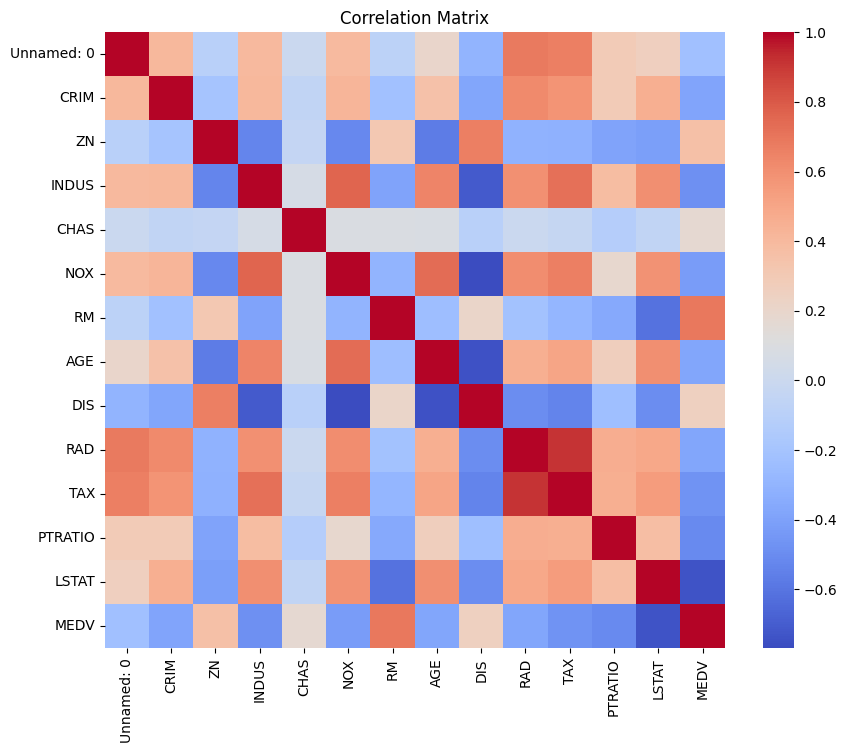

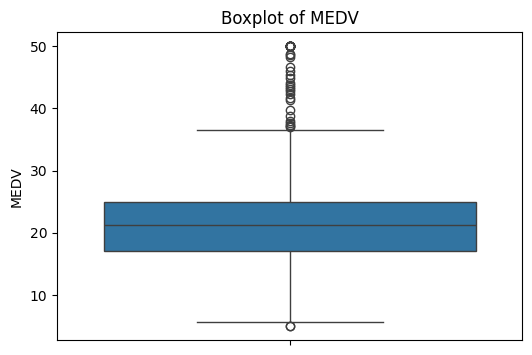

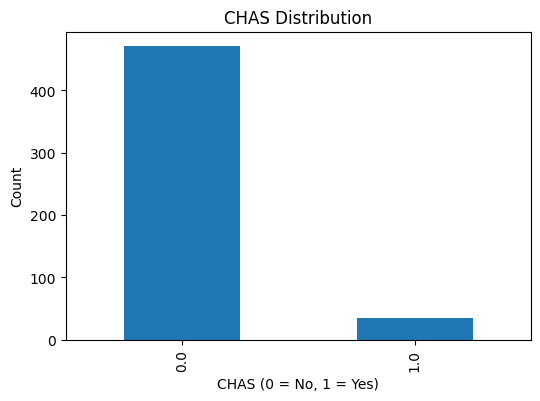

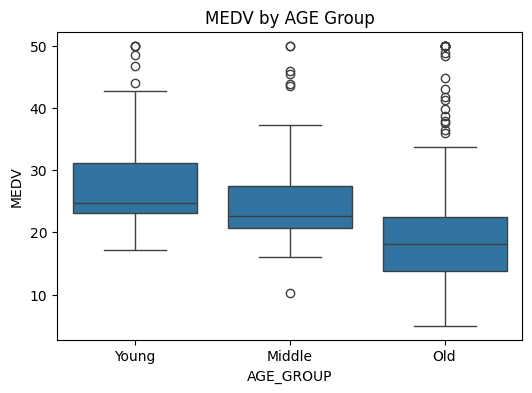

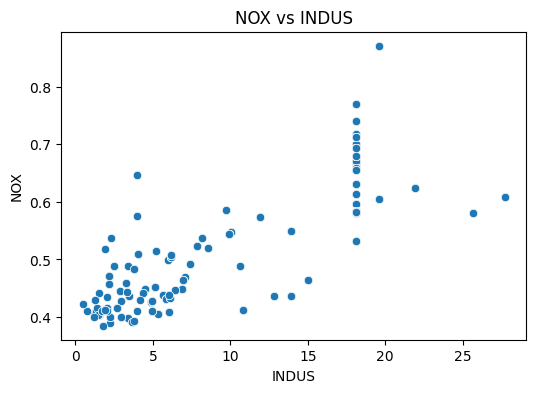

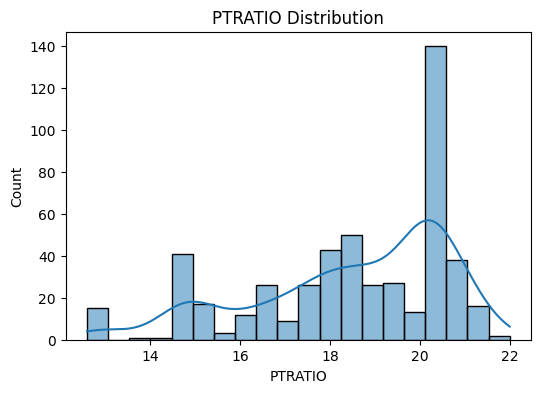

Levene Test: 4.590342218715871 0.03263097600633006
T-test: -3.996437466090509 7.390623170519905e-05
ANOVA: 36.40764999196599 1.7105011022702984e-15
Pearson Correlation: 0.7636514469209192 7.913361061210442e-98
                            OLS Regression Results                            
Dep. Variable:                   MEDV   R-squared:                       0.062
Model:                            OLS   Adj. R-squared:                  0.061
Method:                 Least Squares   F-statistic:                     33.58
Date:                Tue, 10 Mar 2026   Prob (F-statistic):           1.21e-08
Time:                        20:12:44   Log-Likelihood:                -1823.9
No. Observations:                 506   AIC:                             3652.
Df Residuals:                     504   BIC:                             3660.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         


In [12]:
# -------------------------------------------------------
# INSTALL PACKAGES (JupyterLite / Pyodide compatible)
# -------------------------------------------------------
import piplite
await piplite.install(["pandas"])
await piplite.install(["numpy"])
await piplite.install(["seaborn"])
await piplite.install(["matplotlib"])
await piplite.install(["scipy"])
await piplite.install(["statsmodels"])

# -------------------------------------------------------
# IMPORTS
# -------------------------------------------------------
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.formula.api import ols

from js import fetch
import io

# -------------------------------------------------------
# LOAD DATA (Pyodide method)
# -------------------------------------------------------
URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ST0151EN-SkillsNetwork/labs/boston_housing.csv"
resp = await fetch(URL)
boston_bytes = io.BytesIO((await resp.arrayBuffer()).to_py())
df = pd.read_csv(boston_bytes)

# -------------------------------------------------------
# TASK 1: DATA OVERVIEW
# -------------------------------------------------------

df.head()                # First 5 rows
df.dtypes                # Data types
df.isna().sum()          # Missing values
df.duplicated().sum()    # Duplicate rows

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

# -------------------------------------------------------
# TASK 2: DESCRIPTIVE STATISTICS & VISUALS
# -------------------------------------------------------

df.describe()

# Boxplot MEDV
plt.figure(figsize=(6,4))
sns.boxplot(y=df["MEDV"])
plt.title("Boxplot of MEDV")
plt.show()

# Bar plot CHAS
plt.figure(figsize=(6,4))
df["CHAS"].value_counts().plot(kind="bar")
plt.title("CHAS Distribution")
plt.xlabel("CHAS (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

# AGE groups
bins = [0, 35, 70, 100]
labels = ["Young", "Middle", "Old"]
df["AGE_GROUP"] = pd.cut(df["AGE"], bins=bins, labels=labels, include_lowest=True)

plt.figure(figsize=(6,4))
sns.boxplot(x="AGE_GROUP", y="MEDV", data=df)
plt.title("MEDV by AGE Group")
plt.show()

# Scatter NOX vs INDUS
plt.figure(figsize=(6,4))
sns.scatterplot(x="INDUS", y="NOX", data=df)
plt.title("NOX vs INDUS")
plt.show()

# Histogram PTRATIO
plt.figure(figsize=(6,4))
sns.histplot(df["PTRATIO"], bins=20, kde=True)
plt.title("PTRATIO Distribution")
plt.show()

# -------------------------------------------------------
# TASK 3: STATISTICAL TESTS
# -------------------------------------------------------

# Levene test
medv_chas0 = df[df["CHAS"] == 0]["MEDV"]
medv_chas1 = df[df["CHAS"] == 1]["MEDV"]
levene_stat, levene_p = stats.levene(medv_chas0, medv_chas1)
print("Levene Test:", levene_stat, levene_p)

# T-test
t_stat, t_p = stats.ttest_ind(medv_chas0, medv_chas1, equal_var=True)
print("T-test:", t_stat, t_p)

# ANOVA
groups = [df[df["AGE_GROUP"] == g]["MEDV"].dropna() for g in labels]
anova_stat, anova_p = stats.f_oneway(*groups)
print("ANOVA:", anova_stat, anova_p)

# Pearson correlation
pearson_r, pearson_p = stats.pearsonr(df["NOX"], df["INDUS"])
print("Pearson Correlation:", pearson_r, pearson_p)

# Linear regression
model = ols("MEDV ~ DIS", data=df).fit()
print(model.summary())
